Epoch 1/20
5058/5058 ━━━━━━━━━━━━━━━━━━━━ 63s 12ms/step - accuracy: 0.6810 - loss: 0.8595 - val_accuracy: 0.0551 - val_loss: 9.4407
Epoch 2/20
5058/5058 ━━━━━━━━━━━━━━━━━━━━ 61s 12ms/step - accuracy: 0.7978 - loss: 0.4255 - val_accuracy: 0.1201 - val_loss: 8.1453
Epoch 3/20
5058/5058 ━━━━━━━━━━━━━━━━━━━━ 66s 13ms/step - accuracy: 0.8248 - loss: 0.3669 - val_accuracy: 0.1166 - val_loss: 7.3288
Epoch 4/20
5058/5058 ━━━━━━━━━━━━━━━━━━━━ 61s 12ms/step - accuracy: 0.9143 - loss: 0.2145 - val_accuracy: 0.1489 - val_loss: 7.4835
Epoch 5/20
5058/5058 ━━━━━━━━━━━━━━━━━━━━ 61s 12ms/step - accuracy: 0.9312 - loss: 0.1663 - val_accuracy: 0.2053 - val_loss: 8.0847
Epoch 6/20
5058/5058 ━━━━━━━━━━━━━━━━━━━━ 61s 12ms/step - accuracy: 0.9409 - loss: 0.1444 - val_accuracy: 0.1766 - val_loss: 7.5618
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
[[  0   0   0 ...   0   0   0]
 [  1 388   1 ...   0   0   0]
 [  0   1   0 ...   0   0   0]
 ...
 [  0   1   0 ...   0   0   0]
 [  0   2   0 ...   0   1   0]
 [  0  

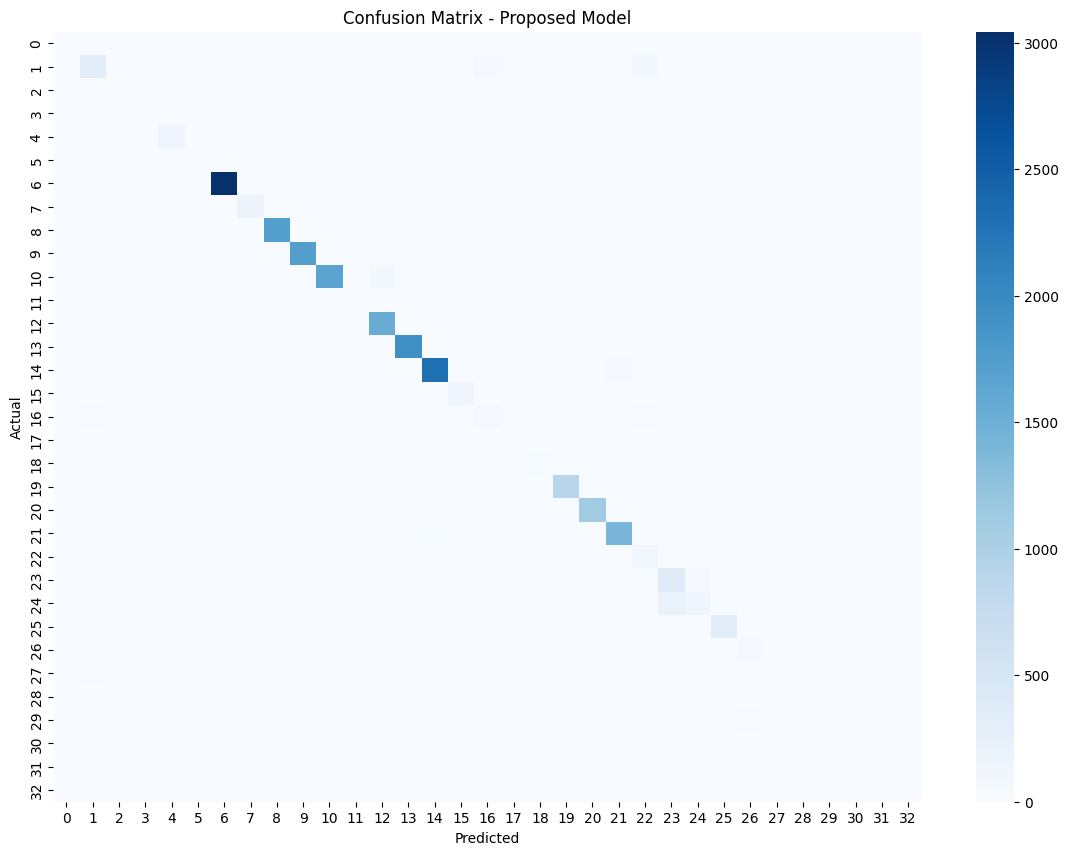

Epoch 1/20
5058/5058 ━━━━━━━━━━━━━━━━━━━━ 62s 12ms/step - accuracy: 0.9153 - loss: 0.2109 - val_accuracy: 0.1729 - val_loss: 7.3626
Epoch 2/20
5058/5058 ━━━━━━━━━━━━━━━━━━━━ 62s 12ms/step - accuracy: 0.9330 - loss: 0.1613 - val_accuracy: 0.1999 - val_loss: 6.8290
Epoch 3/20
5058/5058 ━━━━━━━━━━━━━━━━━━━━ 63s 12ms/step - accuracy: 0.9431 - loss: 0.1430 - val_accuracy: 0.1927 - val_loss: 7.5027
Epoch 4/20
5058/5058 ━━━━━━━━━━━━━━━━━━━━ 69s 14ms/step - accuracy: 0.9533 - loss: 0.1262 - val_accuracy: 0.1816 - val_loss: 7.5430
Epoch 5/20
5058/5058 ━━━━━━━━━━━━━━━━━━━━ 63s 12ms/step - accuracy: 0.9590 - loss: 0.1149 - val_accuracy: 0.2131 - val_loss: 8.0266
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
[[  0   0   0 ...   0   0   0]
 [  1 387   1 ...   0   0   0]
 [  0   1   0 ...   0   0   0]
 ...
 [  0   0   0 ...   0   0   0]
 [  0   2   0 ...   0   3   0]
 [  0   0   0 ...   0   0   0]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Load dataset
df = pd.read_csv("/kaggle/input/datasets/himadri07/ciciot2023/CICIOT23/train/train.csv")

# Clean data
df = df.dropna()
df = df.drop_duplicates()

# Sample data
df = df.sample(100000, random_state=42)

# Remove ultra-rare classes (minimum 5 samples)
counts = df['label'].value_counts()
valid_classes = counts[counts >= 5].index
df = df[df['label'].isin(valid_classes)]

# Features and target
X = df.drop("label", axis=1)
y = df["label"]

# Convert categorical features
X = pd.get_dummies(X)

# Encode target labels
le = LabelEncoder()
y = le.fit_transform(y)

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# SMOTE correction for minority classes
sm = SMOTE(random_state=42, k_neighbors=1)
X_train, y_train = sm.fit_resample(X_train, y_train)

# Reshape for CNN
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Count classes
num_classes = len(np.unique(y_train))

# Convert labels to categorical
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# CNN modelimport pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Load dataset
df = pd.read_csv("/kaggle/input/datasets/himadri07/ciciot2023/CICIOT23/train/train.csv")

# Clean data
df = df.dropna()
df = df.drop_duplicates()

# Sample data
df = df.sample(100000, random_state=42)

# Remove ultra-rare classes (minimum 5 samples)
counts = df['label'].value_counts()
valid_classes = counts[counts >= 5].index
df = df[df['label'].isin(valid_classes)]

# Features and target
X = df.drop("label", axis=1)
y = df["label"]

# Convert categorical features
X = pd.get_dummies(X)

# Encode target labels
le = LabelEncoder()
y = le.fit_transform(y)

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# SMOTE correction for minority classes
sm = SMOTE(random_state=42, k_neighbors=1)
X_train, y_train = sm.fit_resample(X_train, y_train)

# Reshape for CNN
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Count classes
num_classes = len(np.unique(y_train))

# Convert labels to categorical
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# CNN model
model = Sequential([
    Input(shape=(X_train.shape[1], 1)),

    Conv1D(128, 4, activation='relu'),
    MaxPooling1D(2),

    Conv1D(64, 3, activation='relu'),
    MaxPooling1D(2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train_cat,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

# Predict
y_pred = np.argmax(model.predict(X_test), axis=1)

# Results
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))
plt.figure(figsize=(14,10))
sns.heatmap(cm, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Proposed Model")
plt.show()



# Train model
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train_cat,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

# Predict
y_pred = np.argmax(model.predict(X_test), axis=1)

# Results
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))


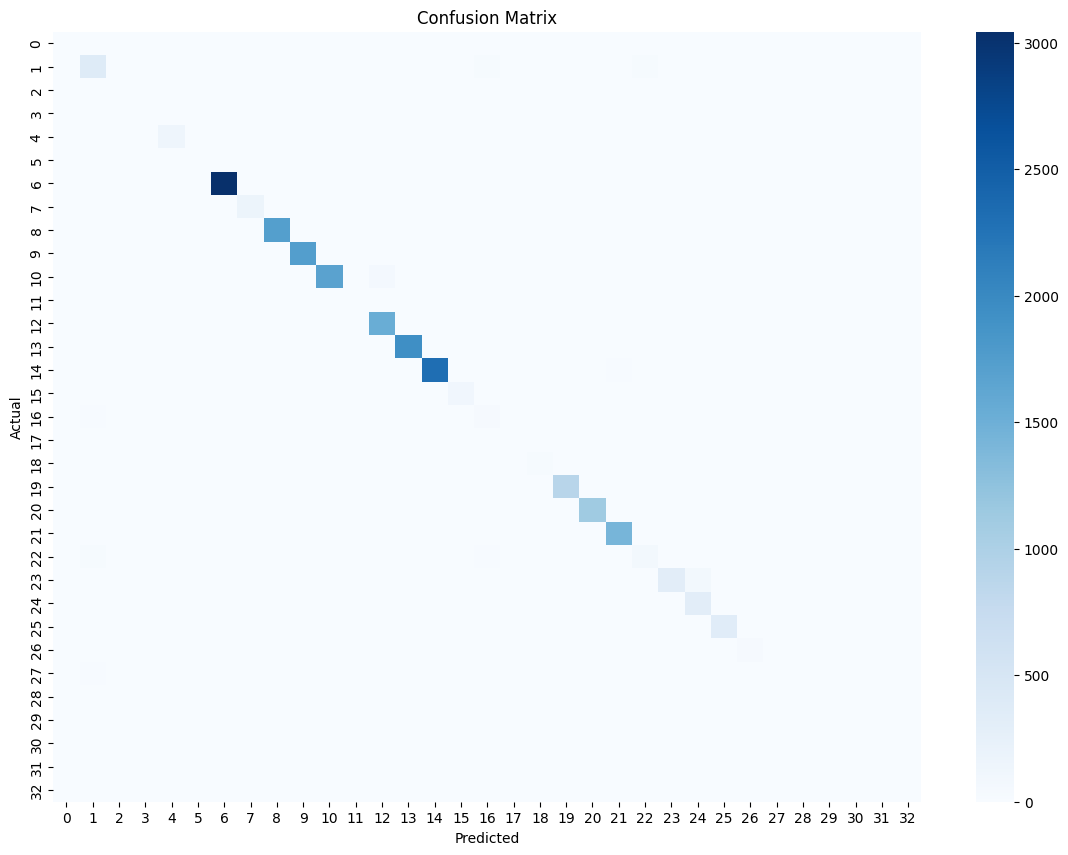

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14,10))
sns.heatmap(cm, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("/kaggle/working/confusion_matrix.png")
plt.show()


In [17]:
report = classification_report(y_test, y_pred)

with open("/kaggle/working/classification_report.txt", "w") as f:
    f.write(report)
df.to_csv("/kaggle/working/output.csv", index=False)
model.save("/kaggle/working/hybrid_model_CICIoT2023.h5")


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
